# Topic Modeling with LDA (fast, classic approach)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CDAC-lab/BUS3005-Resources/blob/main/NLP_3_Topic_Modeling_LDA.ipynb)

**Topic modeling** automatically discovers the main **themes** running through a large collection of text, and groups documents by theme &mdash; all *without anyone labelling the data first* (it is **unsupervised**).

This notebook uses **LDA (Latent Dirichlet Allocation)**, the classic, traditional topic-modeling algorithm. Unlike newer neural methods (such as BERTopic), LDA does **not** need a language model, embeddings, or a GPU &mdash; so it runs in **seconds**, which makes it perfect for quick demos and for learning the core idea.

**The intuition behind LDA.** LDA assumes:

 * every **topic** is a *mixture of words* (e.g. a "space" topic leans on *orbit, launch, nasa*), and
 * every **document** is a *mixture of topics* (a post might be 70% space, 30% technology).

LDA reads the whole collection and works backwards to figure out the hidden topics that best explain the words it sees. We'll then **visualise** those topics. Click the **Play** icon beside each cell, top to bottom.


LDA lives in **scikit-learn**, which Colab already has installed &mdash; so there's almost nothing to install. We only add two small libraries for the visualisations. This takes a few seconds.


In [39]:
#@title Install and import software libraries
!pip install pyldavis wordcloud --quiet

import warnings
warnings.filterwarnings("ignore") # hide warning messages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.lda_model

print("Libraries ready.")

Libraries ready.


## A sample dataset

We'll use the classic **20 Newsgroups** dataset &mdash; forum posts across different discussion groups &mdash; which ships with scikit-learn (no manual download). To keep the demo fast and readable we take posts from four clearly different groups (space, cars, medicine, and computer graphics) and let LDA *rediscover* those themes on its own.


In [40]:
categories = ["sci.space", "rec.autos", "sci.med", "comp.graphics"]

data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),   # strip boilerplate so topics reflect real content
    random_state=42,
)

docs = [d.strip() for d in data.data if len(d.strip()) > 40]
print(f"Loaded {len(docs)} documents.")
print("\nExample document:\n")
print(docs[0][:400], "...")

Loaded 2255 documents.

Example document:

: A very kind soul has mailed me this reply for the bugs in CView.
: Since he isn't in the position to post this himself, he asked me to post
: it for him, but to leave his name out. So here it comes:
: 
: CView has quite a number of bugs.  The one you mention is perhaps the most
:
A stupid question, but what will CView run on and where can I get it? I
am still in need of a GIF viewer for Linux. ( ...


## Step 1: Turn text into a word-count table

LDA works with **word counts**. We use scikit-learn's `CountVectorizer` to build a *document-term matrix*: one row per document, one column per word, and each cell holding how many times that word appears.

We also:

 * remove common English **stopwords** (*the*, *and*, *is* &mdash; they carry no theme), and
 * ignore words that are **too rare** (`min_df`) or **too common** (`max_df`) to be useful.


In [41]:
# Combine standard stop words with your domain-specific noise words
custom_stop_words = list(ENGLISH_STOP_WORDS.union([
    # Conversational noise / filler
    'just', 'like', 'think', 'know', 'people', 'time', 'good', 'new',
    'don', 've', 're', 'll', 'does', 'use', 'used', 'way', 'say', 'make',
    # Internet/Header artifacts
    'edu', 'com', 'mail', 'send', 'available', 'information', 'article', 'writes'
]))

vectorizer = CountVectorizer(
    max_df=0.85,        # ignore words appearing in >90% of docs (too common)
    min_df=5,          # ignore words appearing in fewer than 5 docs (too rare)
    stop_words=custom_stop_words,
    token_pattern=r'(?u)\b[a-zA-Z]{3,}\b', # Keeps only letters, ignores numbers & 1-2 letter words
    max_features=1000, # keep the 1000 most informative words
)

dtm = vectorizer.fit_transform(docs)   # the document-term matrix
vocab = vectorizer.get_feature_names_out()
print(f"Document-term matrix shape: {dtm.shape}  (documents x words)")

Document-term matrix shape: (2255, 1000)  (documents x words)


## Step 2: Fit the LDA model

Now we run LDA. We only have to tell it **how many topics** to look for. We picked four because we know we sampled four groups &mdash; but in real life choosing this number involves some experimentation.

Watch how fast this is &mdash; usually **under a few seconds**.


In [42]:
N_TOPICS = 4

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    learning_method="batch",
    max_iter=25,
    random_state=42,     # fixed seed -> everyone gets the same topics
)
lda.fit(dtm)
print(f"Done! LDA found {N_TOPICS} topics.")

Done! LDA found 4 topics.


## Step 3: What are the topics?

Each topic is defined by the words most strongly associated with it. Let's print the **top words** for each topic and read off what they seem to be about.


In [43]:
def top_words(model, feature_names, n=10):
    rows = []
    for k, comp in enumerate(model.components_):
        top = [feature_names[i] for i in comp.argsort()[::-1][:n]]
        rows.append({"topic": k, "top words": ", ".join(top)})
    return pd.DataFrame(rows)

top_words_df = top_words(lda, vocab, n=10)
pd.set_option("display.max_colwidth", None)
top_words_df

,topic,top words
0,0,"image, graphics, software, file, ftp, jpeg, data, files, images, program"
1,1,"health, medical, patients, food, disease, msg, doctor, pain, cancer, water"
2,2,"car, problem, really, right, better, work, did, cars, things, want"
3,3,"space, nasa, launch, earth, orbit, data, satellite, shuttle, lunar, moon"


Reading the keywords, you should be able to recognise the original four themes re-emerging &mdash; something about *space*, something about *cars*, something about *medicine*, and something about *graphics/images* &mdash; even though **LDA was never told the categories.**


| Topic | Keywords | Suggested Label |
| :--- | :--- | :--- |
| Topic 0 | image, graphics, software, file, ftp, jpeg, data, files, images, program | Computer Graphics/Images |
| Topic 1 | health, medical, patients, food, disease, msg, doctor, pain, cancer, water | Medical Science |
| Topic 2 | car, problem, really, right, better, work, did, cars, things, want | Automobiles (Recreation) |
| Topic 3 | space, nasa, launch, earth, orbit, data, satellite, shuttle, lunar, moon | Space Science & Exploration |



## Visualising the topics

### 1. Top words per topic

A picture makes the topics easier to compare. Each panel below shows a topic's strongest words; the longer the bar, the more that word defines the topic.


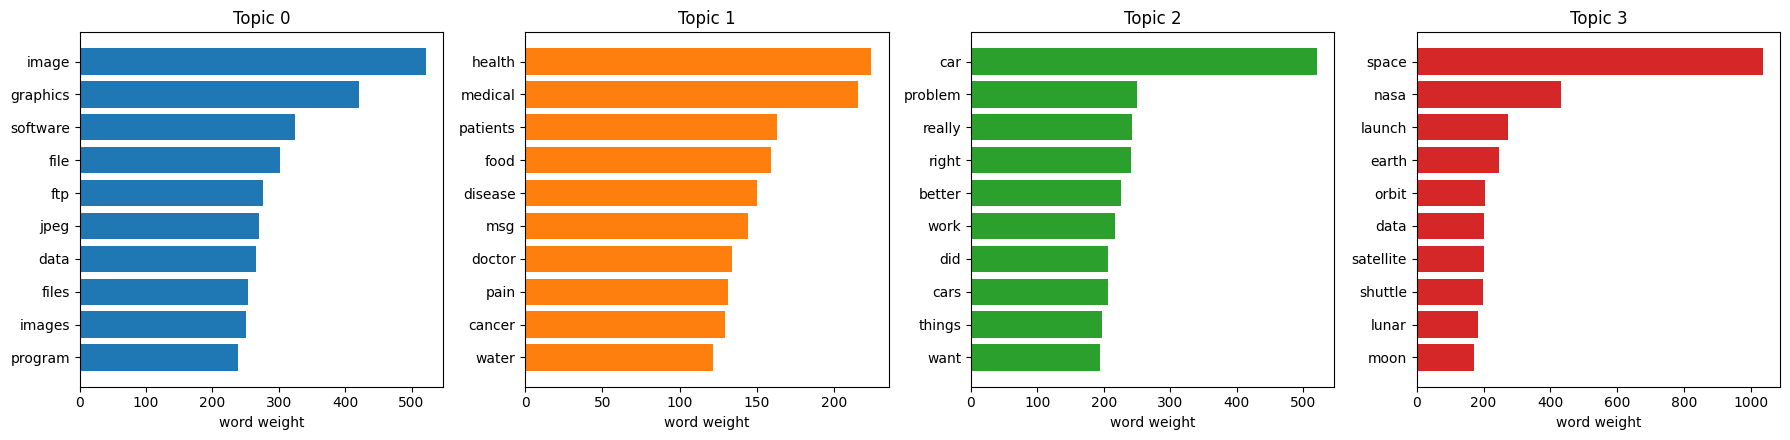

In [44]:
fig, axes = plt.subplots(1, N_TOPICS, figsize=(4.5 * N_TOPICS, 4.5))
for k, ax in enumerate(axes):
    comp = lda.components_[k]
    idx = comp.argsort()[::-1][:10]
    labels = [vocab[i] for i in idx][::-1]
    weights = comp[idx][::-1]
    ax.barh(range(len(labels)), weights, color=plt.cm.tab10(k))
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_title(f"Topic {k}")
    ax.set_xlabel("word weight")
plt.tight_layout()
plt.show()

### 2. A word cloud for each topic

Word clouds show the same information in a more intuitive form: bigger words matter more to the topic.


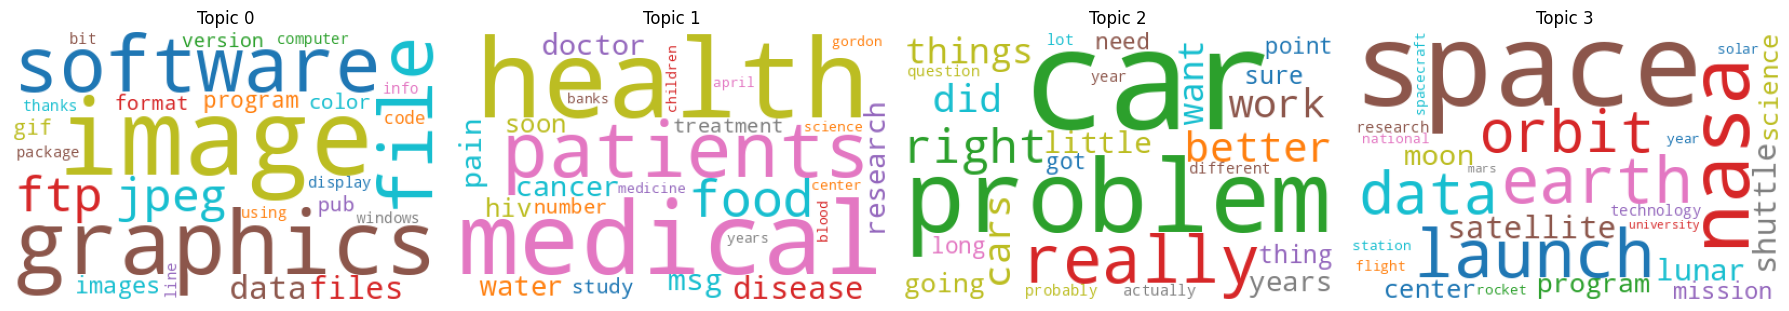

In [45]:
fig, axes = plt.subplots(1, N_TOPICS, figsize=(4.5 * N_TOPICS, 3.2))
for k, ax in enumerate(axes):
    comp = lda.components_[k]
    freqs = {vocab[i]: comp[i] for i in comp.argsort()[::-1][:25]}
    cloud = WordCloud(width=400, height=250, background_color="white",
                      colormap="tab10").generate_from_frequencies(freqs)
    ax.imshow(cloud)
    ax.axis("off")
    ax.set_title(f"Topic {k}")
plt.tight_layout()
plt.show()

### 3. How many documents belong to each topic?

LDA gives every document a *mixture* of topics. If we assign each document to its **strongest** topic, we can see how the collection splits.


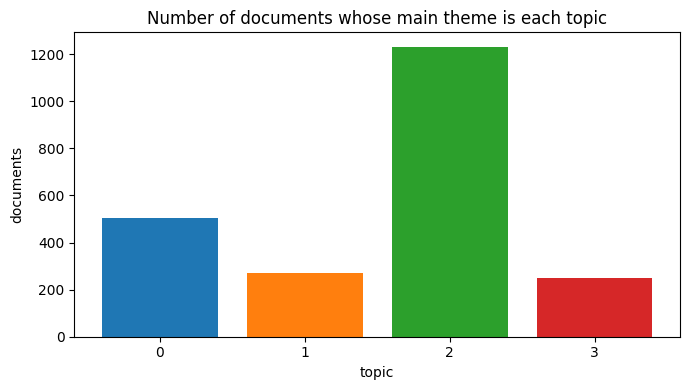

In [46]:
doc_topic = lda.transform(dtm)          # each row: how much of each topic is in that doc
dominant_topic = doc_topic.argmax(axis=1)

counts = pd.Series(dominant_topic).value_counts().sort_index()
plt.figure(figsize=(7, 4))
plt.bar(counts.index.astype(str), counts.values, color=[plt.cm.tab10(k) for k in counts.index])
plt.title("Number of documents whose main theme is each topic")
plt.xlabel("topic")
plt.ylabel("documents")
plt.tight_layout()
plt.show()

### 4. The interactive topic map (pyLDAvis)

`pyLDAvis` builds a rich **interactive** view. Each circle is a topic:

 * **bigger circles** contain more documents, and
 * circles that are **far apart** are more different in meaning.

Click a circle to see its top words on the right; use the slider to adjust how the words are ranked. (This cell takes a few extra seconds to prepare.)


In [47]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.lda_model.prepare(lda, dtm, vectorizer, mds="tsne")
vis

PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
2      34.965176 -61.996002       1        1  34.447322
0      48.668587 -17.354849       2        1  26.333098
3       4.024822  -3.562870       3        1  23.768418
1      -9.659437 -48.213020       4        1  15.451162, topic_info=         Term         Freq        Total Category  logprob  loglift
826     space  1065.000000  1065.000000  Default  30.0000  30.0000
402     image   528.000000   528.000000  Default  29.0000  29.0000
563      nasa   430.000000   430.000000  Default  28.0000  28.0000
362  graphics   417.000000   417.000000  Default  27.0000  27.0000
121       car   508.000000   508.000000  Default  26.0000  26.0000
..        ...          ...          ...      ...      ...      ...
127     cause    81.981832   138.420313   Topic4  -5.1111   1.3437
995     years    90.784275   359.052792   Topic4  -5.0091   0.4925
770   science    85.831061   239.729964   Topic4  -5.0652   0.8404
131    center    87.109306   271.494030   Topic4  -5.0504   0.7307
208       day    80.149382   210.488465   Topic4  -5.1337   0.9019

[250 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
6         1  0.889881  actually
6         2  0.104692  actually
6         4  0.005816  actually
20        1  0.869322       ago
20        2  0.021916       ago
...     ...       ...       ...
994       4  0.136779      year
995       1  0.512459     years
995       3  0.233949     years
995       4  0.253445     years
999       2  0.988182       zip

[393 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 4, 2])

Well-separated circles mean the themes are distinct; overlapping circles mean two topics share a lot of vocabulary. This is a quick way to sanity-check whether your topics are genuinely different.


## Sorting a new document into a topic

Once trained, LDA can place **new, unseen** text into the topics it learned &mdash; useful for tagging incoming articles or tickets.


In [48]:
new_texts = [
    "The rover will launch into orbit to study the surface of Mars.",
    "My engine keeps stalling and the brakes feel loose.",
]

new_dtm = vectorizer.transform(new_texts)      # same word-count vocabulary
new_doc_topic = lda.transform(new_dtm)

for text, dist in zip(new_texts, new_doc_topic):
    best = dist.argmax()
    words = ", ".join(vocab[i] for i in lda.components_[best].argsort()[::-1][:5])
    print(f"Text : {text}")
    print(f"  -> Topic {best}  (keywords: {words})")
    print(f"     full mix: " + ", ".join(f"T{k}:{p:.0%}" for k, p in enumerate(dist)) + "\n")

Text : The rover will launch into orbit to study the surface of Mars.
  -> Topic 3  (keywords: space, nasa, launch, earth, orbit)
     full mix: T0:4%, T1:5%, T2:4%, T3:87%

Text : My engine keeps stalling and the brakes feel loose.
  -> Topic 2  (keywords: car, problem, really, right, better)
     full mix: T0:8%, T1:8%, T2:75%, T3:8%



## Where topic modeling struggles

 * **You choose the number of topics.** Too few merges distinct themes; too many splinters them. Expect to experiment.
 * **You interpret the results.** LDA gives keyword lists; a *human* decides what each topic means and names it.
 * **Bag of words has limits.** LDA ignores word order, so *"not good"* and *"good"* look similar to it.
 * **It needs enough data.** Topics are unreliable on just a handful of short documents.


# Discussion points

 * Do the four discovered topics match the four original newsgroups? Did any split or merge?
 * Re-run with `N_TOPICS = 6`. Do the extra topics reveal real sub-themes, or just noise?
 * LDA gave the new sentences a *mixture* of topics. When is a soft mixture more useful than a single hard label?
 * LDA is much faster than BERTopic but ignores word order and meaning. For which real tasks would that trade-off be fine &mdash; and for which would it not?


# Further reading

 * [**scikit-learn: Topic extraction with LDA/NMF**](https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html) &mdash; the official example.
 * [**pyLDAvis**](https://github.com/bmabey/pyLDAvis) &mdash; the interactive topic visualiser.
 * Blei, D., Ng, A., & Jordan, M. (2003). *Latent Dirichlet Allocation.* JMLR &mdash; the original LDA paper.

---
*This notebook uses scikit-learn's LDA on the 20 Newsgroups dataset, simplified for teaching as a fast, traditional alternative to BERTopic.*
